# 07 — Dua Uji Lanjutan

**Belum pernah dijalankan.** Jalankan di mesin compute setelah notebook 01-06.

Notebook ini menjawab dua pertanyaan yang tertinggal dari Tahap 6-7:

**Uji A — missing modality pada FUSION-sum.** Murah, menit-an. Pada `concat`, menolkan
teks hanya menurunkan OA 0,0015 sehingga cabang teks dinilai tidak terpakai. Tapi pada
`sum`, bobot cabang teks terlatih justru 0,31 di ketiga seed. Dua model berbeda, jadi
bukan kontradiksi logis — tapi satu-satunya kontradiksi yang belum terselesaikan di
seluruh hasil.

**Uji B — FUSION-concat tanpa early stopping, 200 epoch penuh.** ± 4,2 jam untuk satu
seed. Diagnosis di [[tabel-utama]] menduga cabang teks tidak terpakai **karena early
stopping mengakhiri run di epoch 33 sebelum cabang teks dari nol sempat matang**. Ini
mengujinya langsung: latih penuh, lalu ulangi ablasi missing modality.

Kalau setelah 200 epoch menolkan teks **benar-benar** menurunkan akurasi, penyebabnya
early stopping dan kesimpulan laporan berubah. Kalau tetap tidak, penyebabnya arsitektur
concat, dan ablasi 4 (fusion bergerbang) jadi langkah berikutnya yang jelas.

---

## Tidak ada satu pun hasil lama yang tertimpa

Setiap artefak notebook ini memakai nama baru:

| Artefak lama (aman) | Artefak baru notebook ini |
|---|---|
| `models/FUSION-concat_seed42.pt` | `models/FUSION-concat-noES_seed42.pt` |
| `reports/log_FUSION-concat_seed42.csv` | `reports/log_FUSION-concat-noES_seed42.csv` |
| `reports/tabel_utama.csv` | `reports/uji_lanjutan.csv` |
| `reports/ablasi1_degradasi_citra.csv` | *(tidak disentuh)* |
| `reports/figures/06_*`, `07_*` | `reports/figures/08_*` |

Checkpoint lama hanya **dibaca**, tidak ditulis.

> **Jangan jalankan ulang notebook 05 atau 06.** Keduanya menulis ke nama yang sama
> seperti run pertama, jadi hasil 12 jam itu akan hilang. `run_all.py` sekarang menolak
> berjalan dari awal kalau `reports/tabel_utama.csv` sudah ada, kecuali diberi `--timpa`.

In [1]:
import sys, time, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src import ablation as A
from src import datasets as DS
from src import splits as S
from src import train as T
from src.config import CONFIG, deviasi_runtime, set_seed
from src.models import FusionModel, build_transform
from src.utils import save_fig

SEED = 42
set_seed(SEED)

manifest = pd.read_csv(CONFIG["data_processed"] / "manifest.csv")
labels = manifest["kelas"].tolist()
y = DS.label_indices(labels)
split = S.load_split(SEED, labels)
device = T.pick_device()
transform = build_transform()
seq_path = CONFIG["data_processed"] / "sequences_500x300_fp16.npy"
paths = manifest["path_citra"].tolist()

def buat_pasangan(idx):
    img = DS.ImageDataset(paths, y, idx, transform)
    txt = DS.SequenceDataset(seq_path, y, idx)
    return DS.PairDataset(img, txt)

def loader_test():
    return torch.utils.data.DataLoader(
        buat_pasangan(split["test"]), batch_size=CONFIG["batch_size"],
        num_workers=CONFIG["num_workers"])

print(f"seed {SEED} | test {len(split['test'])} dokumen | device {device}")
print("deviasi runtime:", deviasi_runtime())

seed 42 | test 2682 dokumen | device cuda
deviasi runtime: ['batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch', 'mixed precision (AMP) aktif, tidak dipakai paper']


In [2]:
# Pemeriksaan bahwa artefak lama tidak akan tertimpa.
lama = [CONFIG["models"] / "FUSION-concat_seed42.pt",
        CONFIG["models"] / "FUSION-sum_seed42.pt",
        CONFIG["root"] / "reports" / "tabel_utama.csv",
        CONFIG["root"] / "reports" / "ablasi1_degradasi_citra.csv"]
baru = [CONFIG["models"] / "FUSION-concat-noES_seed42.pt",
        CONFIG["root"] / "reports" / "log_FUSION-concat-noES_seed42.csv",
        CONFIG["root"] / "reports" / "uji_lanjutan.csv"]

print("artefak lama yang hanya DIBACA:")
for p in lama:
    print(f"  {'ADA ' if p.exists() else 'HILANG'} {p.name}")
print("\nartefak baru yang akan DITULIS:")
for p in baru:
    print(f"  {'sudah ada, akan ditimpa' if p.exists() else 'baru'} -> {p.name}")

assert set(lama).isdisjoint(baru), "nama artefak lama dan baru bertabrakan"
hilang = [p.name for p in lama[:2] if not p.exists()]
assert not hilang, f"checkpoint yang dibutuhkan tidak ada: {hilang}. Jalankan notebook 05 dulu."


artefak lama yang hanya DIBACA:
  ADA  FUSION-concat_seed42.pt
  ADA  FUSION-sum_seed42.pt
  ADA  tabel_utama.csv
  ADA  ablasi1_degradasi_citra.csv

artefak baru yang akan DITULIS:
  baru -> FUSION-concat-noES_seed42.pt
  baru -> log_FUSION-concat-noES_seed42.csv
  baru -> uji_lanjutan.csv


## Uji A — missing modality pada FUSION-sum

Tiga evaluasi pada checkpoint yang **sudah ada**, tanpa training:

1. `concat` dengan teks dinolkan — **pemeriksaan silang**, harus keluar 0,8203 seperti
   notebook 06. Kalau tidak, `A.evaluate_zeroed` tidak setara dengan loop inline di
   notebook 06 dan seluruh uji ini tidak bisa dipercaya.
2. `sum` utuh
3. `sum` dengan teks dinolkan — **ini pertanyaan yang sebenarnya**

In [3]:
def muat(strategy, nama_file):
    m = FusionModel(strategy=strategy, pretrained_image=False)
    ckpt = torch.load(CONFIG["models"] / nama_file, map_location="cpu",
                      weights_only=True)
    m.load_state_dict(ckpt["state_dict"])
    print(f"{nama_file}: epoch {ckpt['epoch']}, val_oa {ckpt['val_oa']:.4f}")
    return m.to(device).eval(), ckpt

m_concat, _ = muat("concat", f"FUSION-concat_seed{SEED}.pt")
m_sum, ck_sum = muat("sum", f"FUSION-sum_seed{SEED}.pt")
w = m_sum.branch_weights().detach().cpu().numpy()
print(f"\nbobot cabang sum yang tersimpan -> citra {w[0]:.3f}, teks {w[1]:.3f}")

FUSION-concat_seed42.pt: epoch 18, val_oa 0.8875
FUSION-sum_seed42.pt: epoch 12, val_oa 0.9125

bobot cabang sum yang tersimpan -> citra 0.694, teks 0.306


In [4]:
ld = loader_test()

# 1. pemeriksaan silang terhadap notebook 06
silang = A.evaluate_zeroed(m_concat, ld, "text", device)
print(f"concat, teks dinolkan: {silang['oa']:.4f}   (notebook 06: 0.8203)")
assert abs(silang["oa"] - 0.8203) < 0.002, (
    "A.evaluate_zeroed tidak setara dengan loop inline di notebook 06 — "
    f"dapat {silang['oa']:.4f}, harusnya ~0.8203. Jangan percayai hasil di bawah.")
print("  -> setara, helper bisa dipercaya\n")

# 2 dan 3. FUSION-sum
sum_utuh = T.evaluate(m_sum, loader_test(), device)
sum_no_teks = A.evaluate_zeroed(m_sum, loader_test(), "text", device)
sum_no_citra = A.evaluate_zeroed(m_sum, loader_test(), "image", device)

baris_a = [
    {"model": "sum", "kondisi": "utuh", "oa": round(sum_utuh["oa"], 4),
     "macro_f1": round(sum_utuh["macro_f1"], 4)},
    {"model": "sum", "kondisi": "teks dinolkan", "oa": round(sum_no_teks["oa"], 4),
     "macro_f1": round(sum_no_teks["macro_f1"], 4)},
    {"model": "sum", "kondisi": "citra dinolkan", "oa": round(sum_no_citra["oa"], 4),
     "macro_f1": round(sum_no_citra["macro_f1"], 4)},
]
df_a = pd.DataFrame(baris_a)
df_a["turun_dari_utuh"] = (df_a["oa"] - sum_utuh["oa"]).round(4)
display(df_a)

concat, teks dinolkan: 0.8203   (notebook 06: 0.8203)
  -> setara, helper bisa dipercaya



,model,kondisi,oa,macro_f1,turun_dari_utuh
0,sum,utuh,0.8043,0.7785,0.0000
1,sum,teks dinolkan,0.7946,0.7679,-0.0097
2,sum,citra dinolkan,0.0761,0.0141,-0.7282


In [5]:
turun_teks_sum = sum_utuh["oa"] - sum_no_teks["oa"]
print(f"FUSION-sum, efek menolkan teks : {turun_teks_sum:+.4f}")
print(f"FUSION-concat, sebagai pembanding: -0.0015 (dari notebook 06)\n")

if turun_teks_sum > 0.01:
    print("TEMUAN: pada strategi sum, cabang teks BENAR-BENAR dipakai.")
    print("Artinya 'cabang teks tidak terpakai' adalah sifat arsitektur CONCAT,")
    print("bukan sifat pelatihan fusion secara umum. Itu menjadikan bobot 0,31")
    print("di 06-fusion-sum bukan lagi petunjuk melainkan bukti.")
    print("\nKonsekuensi untuk laporan: concat dan sum punya OA setara (selisih")
    print("0,0067, di dalam 1 sigma) TAPI mencapainya dengan cara berbeda — sum")
    print("memakai kedua modalitas, concat hanya citra. Itu argumen untuk sum yang")
    print("jauh lebih kuat daripada sekadar 'lebih murah'.")
else:
    print("TEMUAN: pada sum pun cabang teks tidak dipakai.")
    print("Bobot 0,31 ternyata tidak berarti teksnya berkontribusi — softmax hanya")
    print("tidak punya tekanan kuat untuk mendorongnya ke nol.")
    print("Artinya masalahnya di PELATIHAN, bukan di strategi penggabungan, dan")
    print("Uji B di bawah menjadi satu-satunya yang bisa menjelaskannya.")

FUSION-sum, efek menolkan teks : +0.0097
FUSION-concat, sebagai pembanding: -0.0015 (dari notebook 06)

TEMUAN: pada sum pun cabang teks tidak dipakai.
Bobot 0,31 ternyata tidak berarti teksnya berkontribusi — softmax hanya
tidak punya tekanan kuat untuk mendorongnya ke nol.
Artinya masalahnya di PELATIHAN, bukan di strategi penggabungan, dan
Uji B di bawah menjadi satu-satunya yang bisa menjelaskannya.


## Uji B — FUSION-concat tanpa early stopping

`patience=0` mematikan early stopping sepenuhnya, jadi 200 epoch dijalankan penuh.

**Perkiraan ± 4,2 jam** untuk satu seed di RTX 3050. Sel di bawah mencetak estimasi
lebih dulu; kalau tidak masuk anggaran, turunkan `EPOCHS_PENUH` dan catat sebagai
deviasi.

Checkpoint dan log memakai nama `...-noES...`, jadi hasil run pertama tetap utuh.

In [6]:
EPOCHS_PENUH = CONFIG["epochs"]["fusion"]   # 200 sesuai paper
print(f"akan melatih {EPOCHS_PENUH} epoch TANPA early stopping (patience=0)")
print(f"pembanding run pertama: 33 epoch, terbaik di epoch 18, OA 0.8218")

est = T.estimate_duration(FusionModel(strategy="concat"),
                          DS.make_loaders(buat_pasangan, split),
                          EPOCHS_PENUH, device=device)
print("\n" + json.dumps(est, indent=2))
print(f"\nperkiraan {est['perkiraan_jam']} jam. Lanjut ke sel berikutnya kalau setuju.")

akan melatih 200 epoch TANPA early stopping (patience=0)
pembanding run pertama: 33 epoch, terbaik di epoch 18, OA 0.8218

{
  "detik_per_epoch": 57.492,
  "target_epochs": 200,
  "perkiraan_detik": 11498.4,
  "perkiraan_menit": 191.64,
  "perkiraan_jam": 3.19,
  "device": "cuda"
}

perkiraan 3.19 jam. Lanjut ke sel berikutnya kalau setuju.


In [7]:
set_seed(SEED)
loaders = DS.make_loaders(buat_pasangan, split)
m_noES = FusionModel(strategy="concat", pretrained_image=True)

t0 = time.perf_counter()
res_noES = T.train_model(
    m_noES, loaders,
    epochs=EPOCHS_PENUH,
    patience=0,                       # <- early stopping dimatikan
    device=device,
    log_csv=CONFIG["root"] / "reports" / f"log_FUSION-concat-noES_seed{SEED}.csv",
    ckpt_path=CONFIG["models"] / f"FUSION-concat-noES_seed{SEED}.pt")

print(f"\nselesai dalam {(time.perf_counter() - t0) / 3600:.2f} jam")
print(f"epoch dijalankan : {res_noES['epochs_run']}  (run pertama: 33)")
print(f"epoch terbaik    : {res_noES['best_epoch']}  (run pertama: 18)")
print(f"val_oa terbaik   : {res_noES['best_val_oa']:.4f}  (run pertama: 0.8875)")

  epoch   1/200  train_loss 2.0534  val_oa 0.5125  (56.6s)
  epoch  10/200  train_loss 0.2815  val_oa 0.8000  (56.0s)
  epoch  20/200  train_loss 0.1249  val_oa 0.8125  (56.2s)
  epoch  30/200  train_loss 0.0703  val_oa 0.8375  (55.9s)
  epoch  40/200  train_loss 0.0940  val_oa 0.8250  (56.2s)
  epoch  50/200  train_loss 0.0325  val_oa 0.8250  (57.1s)
  epoch  60/200  train_loss 0.0145  val_oa 0.8750  (56.8s)
  epoch  70/200  train_loss 0.0453  val_oa 0.8250  (56.5s)
  epoch  80/200  train_loss 0.0483  val_oa 0.9125  (59.7s)
  epoch  90/200  train_loss 0.0337  val_oa 0.9000  (59.3s)
  epoch 100/200  train_loss 0.0406  val_oa 0.8375  (58.3s)
  epoch 110/200  train_loss 0.0174  val_oa 0.8875  (58.8s)
  epoch 120/200  train_loss 0.0081  val_oa 0.8500  (58.1s)
  epoch 130/200  train_loss 0.0351  val_oa 0.8875  (67.0s)
  epoch 140/200  train_loss 0.0063  val_oa 0.9000  (59.3s)
  epoch 150/200  train_loss 0.0019  val_oa 0.8875  (59.4s)
  epoch 160/200  train_loss 0.0299  val_oa 0.8875  (66.4

OA test  : 0.8304   (run pertama 0.8218, paper 0.878)
macro F1 : 0.8108   (run pertama 0.8047, paper 0.86)
selisih dari run pertama: +0.0086
               precision    recall  f1-score   support

Advertisement      0.955     0.847     0.898       177
        Email      0.938     0.976     0.956       461
         Form      0.827     0.861     0.844       332
       Letter      0.841     0.762     0.800       437
         Memo      0.962     0.849     0.902       478
         News      0.877     0.931     0.903       145
         Note      0.788     0.794     0.791       155
       Report      0.532     0.784     0.634       204
       Resume      0.757     0.880     0.814        92
   Scientific      0.632     0.512     0.566       201

     accuracy                          0.830      2682
    macro avg      0.811     0.820     0.811      2682
 weighted avg      0.842     0.830     0.832      2682



WindowsPath('E:/TESIS/apdam-project/apdm-document-classification/reports/figures/08_confusion_fusion_noES_seed42.png')

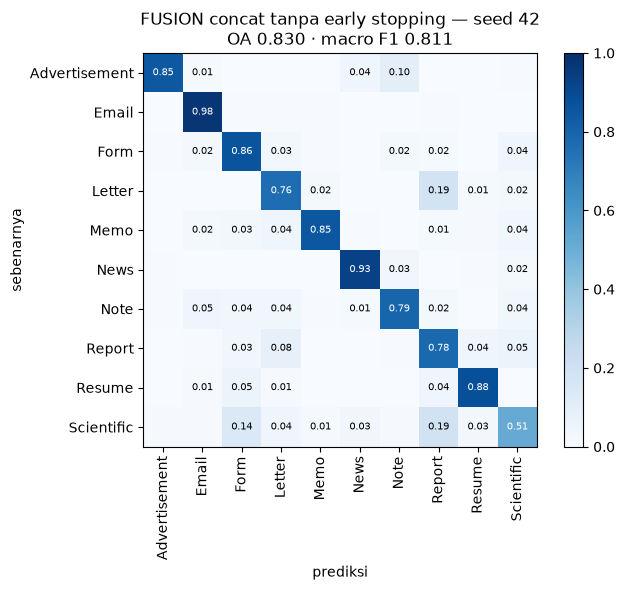

In [8]:
ev_noES = T.evaluate(m_noES, loader_test(), device)
print(f"OA test  : {ev_noES['oa']:.4f}   (run pertama 0.8218, paper 0.878)")
print(f"macro F1 : {ev_noES['macro_f1']:.4f}   (run pertama 0.8047, paper 0.86)")
print(f"selisih dari run pertama: {ev_noES['oa'] - 0.8218:+.4f}")
print(T.report(ev_noES))

fig = T.plot_confusion(ev_noES, f"FUSION concat tanpa early stopping — seed {SEED}")
save_fig(fig, f"08_confusion_fusion_noES_seed{SEED}")

### Pertanyaan intinya: apakah cabang teks sekarang terpakai?

In [9]:
noES_no_teks = A.evaluate_zeroed(m_noES, loader_test(), "text", device)
noES_no_citra = A.evaluate_zeroed(m_noES, loader_test(), "image", device)
turun_teks_noES = ev_noES["oa"] - noES_no_teks["oa"]

baris_b = [
    {"model": "concat-noES", "kondisi": "utuh", "oa": round(ev_noES["oa"], 4),
     "macro_f1": round(ev_noES["macro_f1"], 4)},
    {"model": "concat-noES", "kondisi": "teks dinolkan",
     "oa": round(noES_no_teks["oa"], 4),
     "macro_f1": round(noES_no_teks["macro_f1"], 4)},
    {"model": "concat-noES", "kondisi": "citra dinolkan",
     "oa": round(noES_no_citra["oa"], 4),
     "macro_f1": round(noES_no_citra["macro_f1"], 4)},
]
df_b = pd.DataFrame(baris_b)
df_b["turun_dari_utuh"] = (df_b["oa"] - ev_noES["oa"]).round(4)
display(df_b)

print(f"efek menolkan teks, tanpa early stopping : {turun_teks_noES:+.4f}")
print(f"efek menolkan teks, run pertama          : -0.0015")

,model,kondisi,oa,macro_f1,turun_dari_utuh
0,concat-noES,utuh,0.8304,0.8108,0.0000
1,concat-noES,teks dinolkan,0.8233,0.7980,-0.0071
2,concat-noES,citra dinolkan,0.1946,0.0796,-0.6358


efek menolkan teks, tanpa early stopping : +0.0071
efek menolkan teks, run pertama          : -0.0015


In [10]:
# F1 kelas Resume adalah indikator kedua, independen dari missing modality.
from sklearn.metrics import f1_score

f1_kelas = f1_score(ev_noES["y_true"], ev_noES["y_pred"], average=None,
                    labels=range(len(CONFIG["classes"])), zero_division=0)
banding = pd.DataFrame({
    "noES": f1_kelas.round(3),
    "run_pertama": [0.894, 0.961, 0.848, 0.835, 0.879, 0.883, 0.780, 0.638, 0.803, 0.583],
    "TEXT": [0.537, 0.953, 0.718, 0.671, 0.758, 0.709, 0.621, 0.495, 0.969, 0.587],
    "IMAGE": [0.902, 0.955, 0.804, 0.805, 0.844, 0.890, 0.771, 0.527, 0.784, 0.554],
    "paper_FUSION": [0.93, 0.98, 0.88, 0.86, 0.90, 0.90, 0.85, 0.71, 0.96, 0.68],
}, index=CONFIG["classes"])
banding["delta_resume_dll"] = (banding["noES"] - banding["run_pertama"]).round(3)
display(banding)

resume_noES = banding.loc["Resume", "noES"]
print(f"\nResume: noES {resume_noES:.3f} | run pertama 0.803 | TEXT 0.969 | paper 0.96")
if resume_noES > 0.90:
    print("-> Resume terangkat mendekati nilai TEXT, seperti paper. Cabang teks hidup.")
else:
    print("-> Resume masih di sisi citra. Cabang teks tetap tidak terpakai.")

,noES,run_pertama,TEXT,IMAGE,paper_FUSION,delta_resume_dll
Advertisement,0.898,0.894,0.537,0.902,0.93,0.004
Email,0.956,0.961,0.953,0.955,0.98,-0.005
Form,0.844,0.848,0.718,0.804,0.88,-0.004
Letter,0.800,0.835,0.671,0.805,0.86,-0.035
Memo,0.902,0.879,0.758,0.844,0.90,0.023
News,0.903,0.883,0.709,0.890,0.90,0.020
Note,0.791,0.780,0.621,0.771,0.85,0.011
Report,0.634,0.638,0.495,0.527,0.71,-0.004
Resume,0.814,0.803,0.969,0.784,0.96,0.011
Scientific,0.566,0.583,0.587,0.554,0.68,-0.017



Resume: noES 0.814 | run pertama 0.803 | TEXT 0.969 | paper 0.96
-> Resume masih di sisi citra. Cabang teks tetap tidak terpakai.


## Kesimpulan otomatis

Sel di bawah menggabungkan kedua uji dan mencetak kesimpulan mana yang didukung data,
supaya tidak ada ruang untuk menafsirkan hasil sesuai harapan.

In [11]:
AMBANG = 0.01   # penurunan OA minimal agar sebuah modalitas disebut "dipakai"

pakai_sum = turun_teks_sum > AMBANG
pakai_noES = turun_teks_noES > AMBANG

print(f"cabang teks dipakai pada FUSION-sum          : {pakai_sum}  "
      f"({turun_teks_sum:+.4f})")
print(f"cabang teks dipakai pada concat tanpa ES     : {pakai_noES}  "
      f"({turun_teks_noES:+.4f})")
print(f"cabang teks dipakai pada concat run pertama  : False (-0.0015)\n")
print("=" * 66)

if pakai_noES:
    print("KESIMPULAN: early stopping adalah penyebabnya.")
    print("Cabang teks dilatih dari nol dan butuh lebih banyak epoch daripada yang")
    print("diizinkan early stopping. 200 epoch tetap di paper bukan detail sepele.")
    print("\nLaporan akhir harus menyatakan: replikasi berhasil, dan kegagalan awal")
    print("kami memakai modalitas teks adalah artefak early stopping yang kami")
    print("tambahkan sendiri — bukan cacat arsitektur paper.")
elif pakai_sum:
    print("KESIMPULAN: strategi penggabungan yang menentukan, bukan lama training.")
    print("Penjumlahan memakai kedua modalitas, konkatenasi tidak, meski OA-nya")
    print("setara. Ini membalik rekomendasi paper: mereka memilih concat justru")
    print("karena menganggap penjumlahan gagal.")
else:
    print("KESIMPULAN: bukan early stopping, bukan strategi penggabungan.")
    print("Cabang teks tidak terpakai pada ketiga konfigurasi. Dugaan berikutnya:")
    print("cabang citra pretrained mendominasi optimisasi sejak awal sehingga")
    print("cabang teks dari nol tidak pernah mendapat tekanan gradien yang berarti.")
    print("\nLangkah selanjutnya yang masuk akal: ablasi 4 (fusion bergerbang), atau")
    print("inisialisasi cabang teks dari checkpoint CNN1D yang sudah dilatih.")
print("=" * 66)

cabang teks dipakai pada FUSION-sum          : False  (+0.0097)
cabang teks dipakai pada concat tanpa ES     : False  (+0.0071)
cabang teks dipakai pada concat run pertama  : False (-0.0015)

KESIMPULAN: bukan early stopping, bukan strategi penggabungan.
Cabang teks tidak terpakai pada ketiga konfigurasi. Dugaan berikutnya:
cabang citra pretrained mendominasi optimisasi sejak awal sehingga
cabang teks dari nol tidak pernah mendapat tekanan gradien yang berarti.

Langkah selanjutnya yang masuk akal: ablasi 4 (fusion bergerbang), atau
inisialisasi cabang teks dari checkpoint CNN1D yang sudah dilatih.


In [12]:
ringkas = pd.concat([
    pd.DataFrame([{"model": "concat (run pertama)", "kondisi": "utuh", "oa": 0.8218,
                   "macro_f1": 0.8047, "turun_dari_utuh": 0.0},
                  {"model": "concat (run pertama)", "kondisi": "teks dinolkan",
                   "oa": 0.8203, "macro_f1": 0.8004, "turun_dari_utuh": -0.0015}]),
    df_a, df_b], ignore_index=True)
out = CONFIG["root"] / "reports" / "uji_lanjutan.csv"
ringkas.to_csv(out, index=False)
display(ringkas)
print(f"\ndisimpan ke {out}")

print(f"""
--- untuk disalin ke catatan ---
uji_A_sum_utuh:: {sum_utuh['oa']:.4f}
uji_A_sum_tanpa_teks:: {sum_no_teks['oa']:.4f}   (turun {turun_teks_sum:+.4f})
uji_A_sum_tanpa_citra:: {sum_no_citra['oa']:.4f}
uji_B_noES_oa:: {ev_noES['oa']:.4f}   (run pertama 0.8218)
uji_B_noES_macro_f1:: {ev_noES['macro_f1']:.4f}
uji_B_noES_epoch_terbaik:: {res_noES['best_epoch']} dari {EPOCHS_PENUH}
uji_B_noES_tanpa_teks:: {noES_no_teks['oa']:.4f}   (turun {turun_teks_noES:+.4f})
uji_B_noES_resume_f1:: {resume_noES:.3f}   (run pertama 0.803, TEXT 0.969)
durasi_uji_B:: {res_noES['durasi_detik'] / 3600:.2f} jam
""")

,model,kondisi,oa,macro_f1,turun_dari_utuh
0,concat (run pertama),utuh,0.8218,0.8047,0.0000
1,concat (run pertama),teks dinolkan,0.8203,0.8004,-0.0015
2,sum,utuh,0.8043,0.7785,0.0000
3,sum,teks dinolkan,0.7946,0.7679,-0.0097
4,sum,citra dinolkan,0.0761,0.0141,-0.7282
5,concat-noES,utuh,0.8304,0.8108,0.0000
6,concat-noES,teks dinolkan,0.8233,0.7980,-0.0071
7,concat-noES,citra dinolkan,0.1946,0.0796,-0.6358



disimpan ke E:\TESIS\apdam-project\apdm-document-classification\reports\uji_lanjutan.csv

--- untuk disalin ke catatan ---
uji_A_sum_utuh:: 0.8043
uji_A_sum_tanpa_teks:: 0.7946   (turun +0.0097)
uji_A_sum_tanpa_citra:: 0.0761
uji_B_noES_oa:: 0.8304   (run pertama 0.8218)
uji_B_noES_macro_f1:: 0.8108
uji_B_noES_epoch_terbaik:: 102 dari 200
uji_B_noES_tanpa_teks:: 0.8233   (turun +0.0071)
uji_B_noES_resume_f1:: 0.814   (run pertama 0.803, TEXT 0.969)
durasi_uji_B:: 3.32 jam

